In [1]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/checkpoint-5-bogdan-egor/bogdan/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
likes = load_from_disk('dataset-parts/yambda_likes')
dislikes = load_from_disk('dataset-parts/yambda_dislikes')
listens = load_from_disk('dataset-parts/yambda_listens')

likes_table = likes.data.table
dislikes_table = dislikes.data.table
listens_table = listens.data.table


likes_df: pd.DataFrame = pd.DataFrame.from_arrow(likes_table)
dislikes_df: pd.DataFrame = pd.DataFrame.from_arrow(dislikes_table)
listens_df: pd.DataFrame = pd.DataFrame.from_arrow(listens_table)

likes_df['event_type'] = 'like'
dislikes_df['event_type'] = 'dislike'
listens_df['event_type'] = 'listen'

yambda_df = pd.concat([likes_df, dislikes_df, listens_df], ignore_index=True)
# yambda_df = pd.concat([likes_df, dislikes_df], ignore_index=True)

yambda_df = yambda_df.sort_values('timestamp')

yambda_df

,uid,timestamp,item_id,is_organic,event_type,played_ratio_pct,track_length_seconds
22987762,468300,0,7400764,0,listen,100.0,225.0
17141752,347600,5,3415205,0,listen,100.0,250.0
44880952,942900,10,6728180,0,listen,1.0,270.0
1496718,12700,15,8932363,0,listen,100.0,245.0
12272316,243500,15,5283544,1,listen,100.0,195.0
...,...,...,...,...,...,...,...
45583047,960700,25999995,7430313,0,listen,100.0,135.0
9728746,190700,25999995,875069,0,listen,0.0,235.0
33049843,687600,26000000,2092880,0,listen,12.0,130.0
7631165,144700,26000000,6281650,0,listen,6.0,205.0


In [3]:
yambda_df_organic = yambda_df[yambda_df['is_organic'] == 1].drop(['is_organic'], axis=1)

yambda_df_organic

,uid,timestamp,item_id,event_type,played_ratio_pct,track_length_seconds
12272316,243500,15,5283544,listen,100.0,195.0
21585635,438800,20,5638983,listen,43.0,145.0
21585636,438800,25,8234039,listen,4.0,180.0
37876098,789000,25,3001214,listen,100.0,210.0
35308603,732700,30,4926941,listen,100.0,190.0
...,...,...,...,...,...,...
26845005,554500,25999995,1011428,listen,3.0,115.0
42959512,899900,25999995,3982725,listen,100.0,240.0
42959513,899900,25999995,4027449,listen,100.0,240.0
30923203,645300,25999995,1172812,listen,100.0,120.0


In [4]:
weak_ticks = (7 * 24 * 3600) // 5
year_ticks = (365 * 24 * 3600) // 5

weak_ticks, year_ticks

(120960, 6307200)

In [5]:
max_time = yambda_df_organic['timestamp'].max()

test_start = max_time - weak_ticks
train_start = test_start - year_ticks

In [6]:
train_df = yambda_df_organic[
    (yambda_df_organic['timestamp'] >= train_start) &
    (yambda_df_organic['timestamp'] < test_start)
]

test_df = yambda_df_organic[yambda_df_organic['timestamp'] >= test_start]

Количество уникальных айтемов и пользователей

In [7]:
train_df['item_id'].nunique(), train_df['uid'].nunique()

(396298, 9442)

In [8]:
users_activity = train_df['uid'].value_counts()

In [9]:
users_activity.describe()

count     9442.000000
mean       820.963673
std       1124.074871
min          1.000000
25%         99.000000
50%        414.000000
75%       1078.000000
max      11815.000000
Name: count, dtype: float64

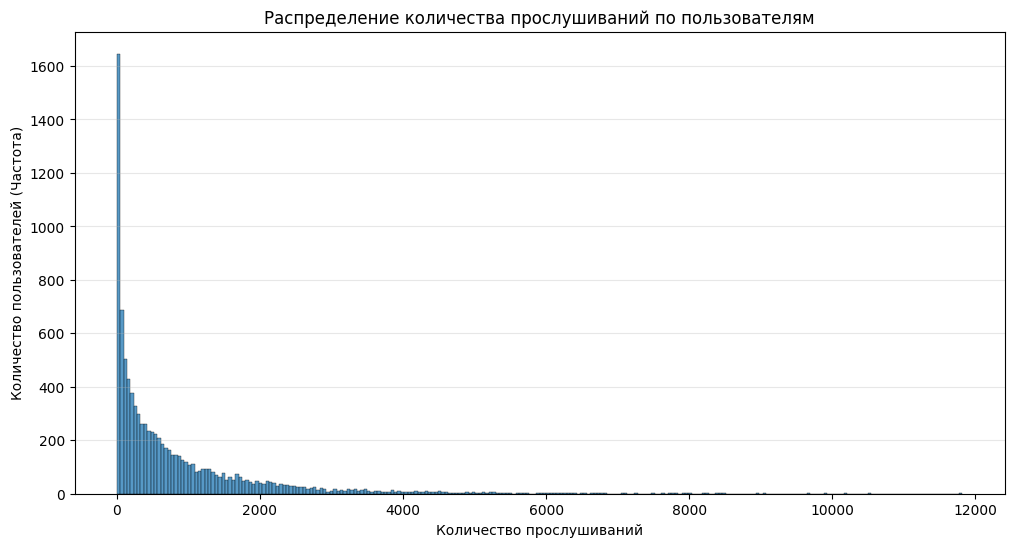

In [10]:
plt.figure(figsize=(12, 6))

sns.histplot(users_activity, bins=250)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='count'>

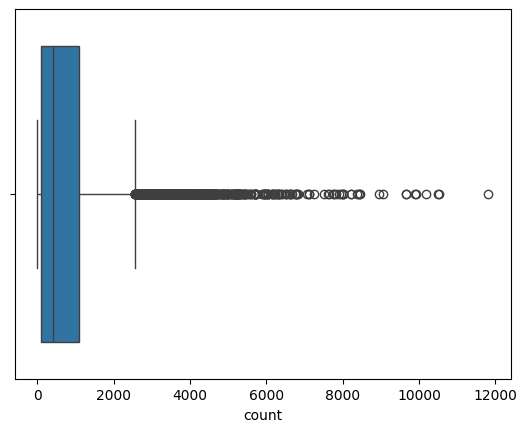

In [11]:
sns.boxplot(x=users_activity)

In [12]:
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999]

for quantile in quantiles:
    print(f'Listens quntile {quantile * 100}%: {users_activity.quantile(quantile)}')

Listens quntile 25.0%: 99.0
Listens quntile 50.0%: 414.0
Listens quntile 75.0%: 1078.0
Listens quntile 80.0%: 1333.0
Listens quntile 90.0%: 2151.8999999999996
Listens quntile 95.0%: 3043.7999999999956
Listens quntile 99.0%: 5265.080000000002
Listens quntile 99.9%: 8731.760999999658


In [13]:

groups = pd.qcut(users_activity, q=[0, 0.3, 0.6, 0.9, 0.95, 1.0], duplicates='drop')

counts = groups.value_counts().sort_index()

print('Users activity distribution')
print(counts)

Users activity distribution
count
(0.999, 142.0]       2835
(142.0, 611.0]       2834
(611.0, 2151.9]      2828
(2151.9, 3043.8]      472
(3043.8, 11815.0]     473
Name: count, dtype: int64


Думаю, что можно взять пользователей между 30 и 90 кватилями  

In [14]:
low_threshold = users_activity.quantile(0.3)
high_threshold = users_activity.quantile(0.9)

active_user_ids = users_activity[
    (users_activity >= low_threshold) & 
    (users_activity <= high_threshold)
].index

df_train_active = train_df[train_df['uid'].isin(active_user_ids)].reset_index(drop=True)

In [15]:
df_train_active['uid'].value_counts().describe()

count    5672.000000
mean      760.155501
std       521.704650
min       142.000000
25%       327.000000
50%       610.000000
75%      1078.000000
max      2151.000000
Name: count, dtype: float64

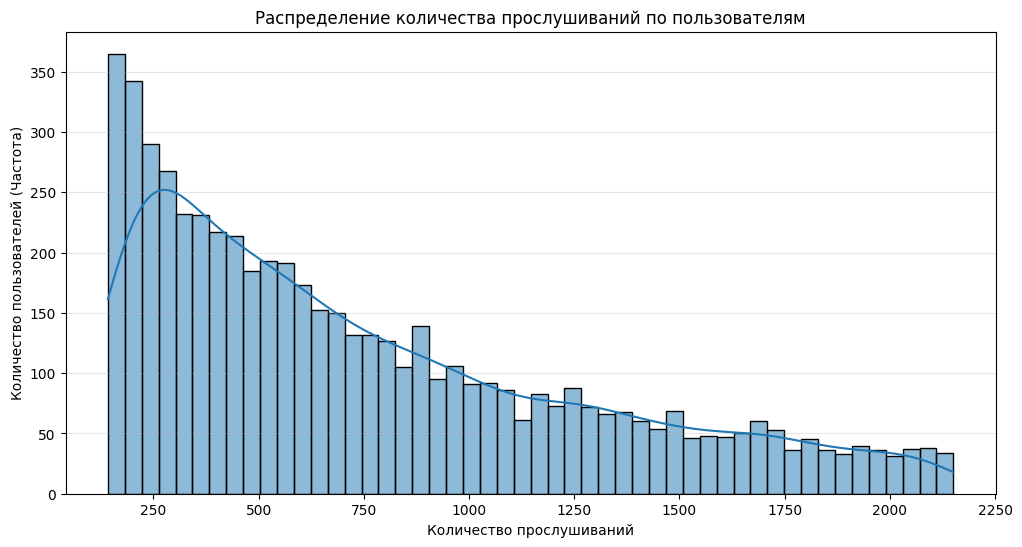

In [16]:
plt.figure(figsize=(12, 6))

sns.histplot(df_train_active['uid'].value_counts(), kde=True, bins=50)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [17]:
df_train_active

,uid,timestamp,item_id,event_type,played_ratio_pct,track_length_seconds
0,912700,19571840,7027100,listen,100.0,250.0
1,912700,19571840,1006437,listen,101.0,150.0
2,912700,19571840,134761,listen,100.0,130.0
3,912700,19571840,4270521,listen,50.0,340.0
4,912700,19571840,1751528,listen,100.0,110.0
...,...,...,...,...,...,...
4311597,695000,25879030,9332992,listen,100.0,190.0
4311598,332100,25879030,238673,listen,100.0,225.0
4311599,994700,25879035,5129354,listen,100.0,135.0
4311600,729100,25879035,8705280,listen,100.0,220.0


In [18]:
df_train_active.item_id.nunique(), df_train_active.uid.nunique()

(312742, 5672)

Сейчас у нас есть следующие формы взаимодействия:
* Лайк
* Дизлайк
* Прослушивание

Сформируем весовую матрицу взаиомодействий:

* Лайк: 1.0
* Дизлайк: 0.01
* Прослушивание: `min(max((mean(track.played_ratio_pct / 100)), 1.0), 0.1)`, т.е получится диапазон от 0.1 до 1.0


In [19]:
df_train_active.event_type.value_counts()

event_type
listen     4211468
like         88924
dislike      11210
Name: count, dtype: int64

In [20]:
train_df[train_df[['played_ratio_pct']].isna().any(axis=1)]['event_type'].value_counts()

event_type
like       171020
dislike     17130
Name: count, dtype: int64

In [ ]:
train_df_sorted = train_df.sort_values(by=['uid', 'item_id', 'timestamp'])

explicit_df = train_df_sorted[train_df_sorted['event_type'].isin(['like', 'dislike'])]
implicit_df = train_df_sorted[train_df_sorted['event_type'] == 'listen']

last_explicit = explicit_df.drop_duplicates(subset=['uid', 'item_id'], keep='last').copy()


listen_agg = (
    implicit_df.groupby(['uid', 'item_id'])['played_ratio_pct']
    .mean()
    .divide(100)
    .clip(0.1, 1.0)
    .reset_index()
).rename(columns={'played_ratio_pct': 'interaction_weighted'})


weight_mapping_weighted = {
    'like': 1,
    'dislike': 0.01,
}

last_explicit['interaction_weighted'] = last_explicit['event_type'].map(weight_mapping_weighted)

last_explicit = last_explicit[['uid', 'item_id', 'interaction_weighted']].reset_index(drop=True)


explicit_part = last_explicit.rename(columns={"interaction_weighted": "w_explicit"})
implicit_part = listen_agg.rename(columns={"interaction_weighted": "w_implicit"})

user_item_weighted = explicit_part.merge(
    implicit_part,
    on=["uid", "item_id"],
    how="outer",
)

user_item_weighted["interaction_weighted"] = user_item_weighted["w_explicit"].combine_first(
    user_item_weighted["w_implicit"]
)

user_item_weighted = user_item_weighted[["uid", "item_id", "interaction_weighted"]]

# user_item_weighted = pd.concat([last_explicit, listen_agg], ignore_index=True)

In [22]:
user_item_weighted

,uid,item_id,interaction_weighted
0,100,88111,1.00
1,100,152884,1.00
2,100,155792,0.93
3,100,225669,1.00
4,100,286361,1.00
...,...,...,...
2497418,1000000,8323008,1.00
2497419,1000000,8374442,0.30
2497420,1000000,8732545,0.72
2497421,1000000,8750380,0.99


In [24]:
train_users_weighted = set(user_item_weighted['uid'])
train_items_weighted = set(user_item_weighted['item_id'])

test_clean = test_df[
    test_df['uid'].isin(train_users_weighted) &
    test_df['item_id'].isin(train_items_weighted)
]

In [25]:
item2id = {k: v for v, k in enumerate(user_item_weighted['item_id'].unique())}
user2id = {k: v for v, k in enumerate(user_item_weighted['uid'].unique())}

id2item = {v: k for k, v in item2id.items()}
id2user = {v: k for k, v in user2id.items()}

In [26]:
user_item_weighted['uidx'] = user_item_weighted['uid'].map(user2id)
user_item_weighted['item_idx'] = user_item_weighted['item_id'].map(item2id)

In [27]:
user_item_weighted

,uid,item_id,interaction_weighted,uidx,item_idx
0,100,88111,1.00,0,0
1,100,152884,1.00,0,1
2,100,155792,0.93,0,2
3,100,225669,1.00,0,3
4,100,286361,1.00,0,4
...,...,...,...,...,...
2497418,1000000,8323008,1.00,9441,53227
2497419,1000000,8374442,0.30,9441,3493
2497420,1000000,8732545,0.72,9441,3526
2497421,1000000,8750380,0.99,9441,11943


In [28]:
user_item_weighted['uid'].nunique(), user_item_weighted['item_id'].nunique()

(9442, 396298)

In [29]:
from scipy.sparse import csr_matrix

user_item_weighted_sparse = csr_matrix(
    (
        user_item_weighted['interaction_weighted'],
        (user_item_weighted['uidx'], user_item_weighted['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

Metrics import 

In [30]:
from metrics import (
    recall_at_k,
    precision_at_k,
    ndcg_at_k,
    map_at_k,
    hit_rate_at_k,
)

Истинные взаимодействия, пока без разделения на лайки/дизлайки

In [31]:
test_true = test_clean.groupby('uid')['item_id'].apply(set).to_dict()

UserKNN

In [ ]:
from models import UserKNN

In [ ]:
userknn_weighted = UserKNN()
userknn_weighted.fit(user_item_weighted_sparse)

In [ ]:
recall_userknn_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
precision_userknn_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
ndcg_userknn_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
map_userknn_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
hit_rate_userknn_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)

print('UserKNN weighted NDCG@10:', ndcg_userknn_weighted)
print('UserKNN weighted Recall@10:', recall_userknn_weighted)
# print('UserKNN weighted Precision@10:', precision_userknn_weighted)
print('UserKNN weighted MAP@10:', map_userknn_weighted)
print('UserKNN weighted HitRate@10:', hit_rate_userknn_weighted)


UserKNN weighted NDCG@10: 0.007921492963786986
UserKNN weighted Recall@10: 0.0024958327701941705
UserKNN weighted MAP@10: 0.00400333931873923
UserKNN weighted HitRate@10: 0.03844454264250994


ItemKNN

In [ ]:
from models import ItemKNN

In [ ]:
itemknn_weighted = ItemKNN()
itemknn_weighted.fit(user_item_weighted_sparse)

: 

In [ ]:
recall_itemknn_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
precision_itemknn_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
ndcg_itemknn_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
map_itemknn_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
hit_rate_itemknn_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)

print('ItemKNN weighted NDCG@10:', ndcg_itemknn_weighted)
print('ItemKNN weighted Recall@10:', recall_itemknn_weighted)
# print('ItemKNN weighted Precision@10:', precision_itemknn_weighted)
print('ItemKNN weighted MAP@10:', map_itemknn_weighted)
print('ItemKNN weighted HitRate@10:', hit_rate_itemknn_weighted)


NameError: name 'itemknn_weighted' is not defined

ELSA


In [32]:
from models import ELSA

In [33]:
elsa_weighted = ELSA()
elsa_weighted.fit(user_item_weighted_sparse)


In [34]:
recall_elsa_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
precision_elsa_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
ndcg_elsa_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
map_elsa_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
hit_rate_elsa_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)

print('ELSA weighted NDCG@10:', ndcg_elsa_weighted)
print('ELSA weighted Recall@10:', recall_elsa_weighted)
print('ELSA weighted Precision@10:', precision_elsa_weighted)
print('ELSA weighted MAP@10:', map_elsa_weighted)
print('ELSA weighted HitRate@10:', hit_rate_elsa_weighted)


ELSA weighted NDCG@10: 0.01147924134336772
ELSA weighted Recall@10: 0.00434292922467
ELSA weighted Precision@10: 0.010649580203269995
ELSA weighted MAP@10: 0.00483897197731157
ELSA weighted HitRate@10: 0.07092355280600972


iALS


In [ ]:
from models import iALS

In [ ]:
ials_weighted = iALS()
ials_weighted.fit(user_item_weighted_sparse)

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/checkpoint-5-bogdan-egor/bogdan/venv/lib/python3.13/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 25/25 [00:34<00:00,  1.40s/it]


In [ ]:
recall_ials_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
precision_ials_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
ndcg_ials_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
map_ials_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
hit_rate_ials_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)

print('iALS weighted NDCG@10:', ndcg_ials_weighted)
print('iALS weighted Recall@10:', recall_ials_weighted)
print('iALS weighted Precision@10:', precision_ials_weighted)
print('iALS weighted MAP@10:', map_ials_weighted)
print('iALS weighted HitRate@10:', hit_rate_ials_weighted)


iALS weighted NDCG@10: 0.012585307142514459
iALS weighted Recall@10: 0.0040726224264540254
iALS weighted Precision@10: 0.009986743261157754
iALS weighted MAP@10: 0.006058309680069144
iALS weighted HitRate@10: 0.06252761820592134


TopPopular, TopPersonal, TopPersonal+TopPopular

In [ ]:
from models import TopPopular, TopPersonal, TopPersonalTopPopular


top_popular_weighted = TopPopular()
top_popular_weighted.fit(user_item_weighted_sparse)


top_personal_weighted = TopPersonal()
top_personal_weighted.fit(user_item_weighted_sparse)


hybrid_weighted = TopPersonalTopPopular()
hybrid_weighted.fit(user_item_weighted_sparse)


In [ ]:
def print_metrics_all(label, model, R, k=10):
    fn = model.predict
    print(f"=== {label} ===")
    print(f"Recall@{k}:", recall_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"Precision@{k}:", precision_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"NDCG@{k}:", ndcg_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"MAP@{k}:", map_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"HitRate@{k}:", hit_rate_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print()


for name, m, R in [
    ("TopPopular weighted", top_popular_weighted, user_item_weighted_sparse),
    ("TopPersonal weighted", top_personal_weighted, user_item_weighted_sparse),
    ("TopPersonal+TopPopular weighted", hybrid_weighted, user_item_weighted_sparse),
]:
    print_metrics_all(name, m, R)


=== TopPopular weighted ===
Recall@10: 0.0018831373609046267
Precision@10: 0.0046177640300486085
NDCG@10: 0.0058001103932470155
MAP@10: 0.0028844607698728336
HitRate@10: 0.028501988510826335

=== TopPersonal weighted ===
Recall@10: 0.0024958327701941705
Precision@10: 0.006120194432169686
NDCG@10: 0.007921492963786986
MAP@10: 0.00400333931873923
HitRate@10: 0.03844454264250994

=== TopPersonal+TopPopular weighted ===
Recall@10: 0.0020363112132270127
Precision@10: 0.004993371630578877
NDCG@10: 0.006957215608966453
MAP@10: 0.003674622025124676
HitRate@10: 0.03159522757401679

